# 07 — Persiapan dan Labeling Sentimen Dataset Cleaned Komentar YouTube

## Project
**Analisis Sentimen Komentar YouTube terhadap Isu Pelemahan Nilai Rupiah dan Dampaknya terhadap Persepsi Daya Beli Masyarakat Menggunakan Python, Jupyter Notebook, GitHub, dan Streamlit**

Notebook ini merupakan tahap ketujuh dari alur kerja project Data Mining. Fokus utama tahap ini adalah menyiapkan dataset hasil cleaning untuk diberi label sentimen awal menggunakan pendekatan berbasis aturan atau lexicon sederhana.

Label yang digunakan terdiri dari:

1. `positif`
2. `negatif`
3. `netral`

Label yang dihasilkan pada tahap ini merupakan **label awal / pseudo-label**, bukan ground truth final. Oleh karena itu, hasil labeling masih perlu ditinjau secara kritis, terutama apabila nantinya digunakan sebagai dasar untuk pemodelan machine learning pada tahap berikutnya.

## 1. Tujuan Tahap

Tujuan dari tahap ini adalah melakukan persiapan data dan membuat label sentimen awal pada dataset komentar YouTube yang sudah melalui proses cleaning dan text preprocessing.

Secara khusus, tahap ini bertujuan untuk:

1. Membaca dataset cleaned terbaru dari folder `data/processed/`.
2. Memvalidasi keberadaan kolom utama `text_original` dan `text_clean`.
3. Menyiapkan struktur folder output untuk dataset berlabel dan laporan labeling.
4. Menyusun pendekatan labeling sentimen awal berbasis aturan atau lexicon sederhana.
5. Menghasilkan label sentimen awal dengan kategori `positif`, `negatif`, dan `netral`.
6. Menyimpan dataset hasil labeling ke folder `data/labeled/`.
7. Menyimpan ringkasan dan visualisasi distribusi label ke folder `reports/`.

Pada tahap ini belum dilakukan proses TF-IDF, train-test split, training model machine learning, evaluasi model, confusion matrix, maupun deployment aplikasi.

## 2. Output yang Dihasilkan

Output utama dari notebook ini adalah:

1. Dataset komentar YouTube yang sudah memiliki label sentimen awal.
2. Ringkasan distribusi label sentimen.
3. Visualisasi distribusi label sentimen.
4. Laporan ringkas proses labeling.

Output dataset berlabel akan disimpan ke:

`data/labeled/`

Sedangkan laporan dan visualisasi labeling akan disimpan ke:

`reports/`

Catatan penting:

- Dataset raw, dataset processed, dan dataset labeled tidak dipublikasikan ke GitHub karena masih memuat komentar asli.
- File `.env` tidak dibaca dan tidak ditampilkan.
- Kolom `author` tidak ditampilkan pada preview data.
- Preview data dilakukan secara terbatas dan aman.

## 3. Konsep Labeling Sentimen Awal

Labeling sentimen awal pada notebook ini menggunakan pendekatan sederhana berbasis lexicon/rule-based. Pendekatan ini bekerja dengan cara mendeteksi keberadaan kata atau frasa tertentu yang merepresentasikan kecenderungan sentimen positif, negatif, atau netral.

Dalam konteks komentar YouTube tentang pelemahan nilai rupiah dan daya beli masyarakat, komentar dapat mengandung:

- sentimen negatif, misalnya komentar yang menunjukkan keluhan, kekhawatiran, penurunan daya beli, harga naik, ekonomi sulit, atau kritik terhadap kondisi ekonomi;
- sentimen positif, misalnya komentar yang menunjukkan optimisme, dukungan, solusi, harapan, atau keyakinan bahwa kondisi dapat membaik;
- sentimen netral, misalnya komentar informatif, deskriptif, bertanya, atau tidak menunjukkan kecenderungan emosional yang jelas.

Hasil labeling pada tahap ini disebut sebagai **pseudo-label**, yaitu label awal yang dihasilkan secara otomatis berdasarkan aturan tertentu. Pseudo-label belum dapat dianggap sebagai kebenaran final atau ground truth karena masih memiliki potensi kesalahan interpretasi, terutama pada komentar yang mengandung sarkasme, ironi, bahasa gaul, singkatan, atau konteks sosial-politik tertentu.

Dengan demikian, hasil labeling ini perlu dipahami sebagai tahap awal untuk membantu eksplorasi sentimen sebelum dilakukan validasi manual atau pengembangan model machine learning pada tahap berikutnya.

In [1]:
# ============================================================
# 07 — Persiapan dan Labeling Sentimen Dataset Cleaned
# Import library utama
# ============================================================

from pathlib import Path
from datetime import datetime
import re
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mengatur tampilan pandas agar lebih nyaman dibaca
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

print("Library berhasil di-import.")
print("Waktu eksekusi:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Library berhasil di-import.
Waktu eksekusi: 2026-05-29 15:32:44


In [2]:
# ============================================================
# Deteksi project root
# ============================================================

def find_project_root(start_path=None):
    """
    Mendeteksi folder root project secara otomatis.

    Notebook biasanya dijalankan dari folder:
    - root project, atau
    - folder notebooks/

    Fungsi ini akan naik ke parent directory sampai menemukan
    struktur folder yang sesuai dengan project.
    """
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path).resolve()

    current_path = start_path.resolve()

    for path in [current_path] + list(current_path.parents):
        has_notebooks = (path / "notebooks").exists()
        has_data = (path / "data").exists()
        has_reports = (path / "reports").exists()
        has_git = (path / ".git").exists()

        if has_notebooks and has_data:
            return path

        # Alternatif jika folder reports belum ada, tetapi project sudah berupa repo Git
        if has_notebooks and has_git:
            return path

    raise FileNotFoundError(
        "Project root tidak ditemukan. "
        "Pastikan notebook dijalankan dari folder project atau folder notebooks."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
LABELED_DIR = DATA_DIR / "labeled"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Membuat folder output jika belum tersedia
LABELED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root terdeteksi:")
print(PROJECT_ROOT)

print("\nFolder input dataset cleaned:")
print(PROCESSED_DIR)

print("\nFolder output dataset labeled:")
print(LABELED_DIR)

print("\nFolder output reports:")
print(REPORTS_DIR)

Project root terdeteksi:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis

Folder input dataset cleaned:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\processed

Folder output dataset labeled:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\labeled

Folder output reports:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports


In [3]:
# ============================================================
# Deteksi dataset cleaned terbaru dari folder data/processed/
# ============================================================

def detect_latest_cleaned_dataset(processed_dir):
    """
    Mendeteksi file CSV terbaru di folder data/processed/ yang memiliki
    kolom wajib text_original dan text_clean.

    Pendekatan ini lebih aman dibanding hanya mengandalkan nama file,
    karena notebook akan memvalidasi isi kolom sebelum memilih dataset.
    """
    processed_dir = Path(processed_dir)

    if not processed_dir.exists():
        raise FileNotFoundError(f"Folder data/processed tidak ditemukan: {processed_dir}")

    csv_files = sorted(
        processed_dir.glob("*.csv"),
        key=lambda file: file.stat().st_mtime,
        reverse=True
    )

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "Tidak ada file CSV ditemukan di folder data/processed/. "
            "Pastikan output Tahap 05 sudah tersimpan dengan benar."
        )

    required_columns = {"text_original", "text_clean"}
    candidate_files = []

    for file_path in csv_files:
        try:
            # Membaca hanya beberapa baris untuk validasi struktur kolom
            sample_df = pd.read_csv(file_path, nrows=5)
            available_columns = set(sample_df.columns)

            if required_columns.issubset(available_columns):
                candidate_files.append(file_path)

        except Exception as error:
            print(f"File dilewati karena tidak dapat dibaca: {file_path.name}")
            print("Alasan:", error)

    if len(candidate_files) == 0:
        raise FileNotFoundError(
            "Tidak ditemukan file CSV di data/processed/ yang memiliki kolom "
            "'text_original' dan 'text_clean'."
        )

    return candidate_files[0]


latest_cleaned_file = detect_latest_cleaned_dataset(PROCESSED_DIR)

print("Dataset cleaned terbaru berhasil terdeteksi:")
print(latest_cleaned_file.name)

print("\nWaktu modifikasi file:")
print(datetime.fromtimestamp(latest_cleaned_file.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S"))

Dataset cleaned terbaru berhasil terdeteksi:
youtube_comments_cleaned_20260529_150114.csv

Waktu modifikasi file:
2026-05-29 15:01:14


In [4]:
# ============================================================
# Load dataset cleaned secara aman
# ============================================================

df_clean = pd.read_csv(latest_cleaned_file)

print("Dataset cleaned berhasil dibaca.")
print("Nama file:", latest_cleaned_file.name)
print("Jumlah baris:", df_clean.shape[0])
print("Jumlah kolom:", df_clean.shape[1])

# Daftar kolom yang tidak boleh ditampilkan pada preview
SENSITIVE_COLUMNS = {
    "author",
    "author_name",
    "author_display_name",
    "channel_id",
    "author_channel_id"
}

# Membuat daftar kolom aman untuk kebutuhan preview
safe_columns = [col for col in df_clean.columns if col not in SENSITIVE_COLUMNS]

print("\nJumlah kolom yang aman untuk ditampilkan:", len(safe_columns))
print("Catatan: kolom sensitif seperti author tidak akan ditampilkan pada preview.")

Dataset cleaned berhasil dibaca.
Nama file: youtube_comments_cleaned_20260529_150114.csv
Jumlah baris: 3670
Jumlah kolom: 20

Jumlah kolom yang aman untuk ditampilkan: 20
Catatan: kolom sensitif seperti author tidak akan ditampilkan pada preview.


In [5]:
# ============================================================
# Validasi kolom utama
# ============================================================

required_columns = ["text_original", "text_clean"]
missing_required_columns = [col for col in required_columns if col not in df_clean.columns]

if missing_required_columns:
    raise ValueError(
        "Validasi gagal. Kolom wajib berikut tidak ditemukan: "
        + ", ".join(missing_required_columns)
    )

print("Validasi berhasil.")
print("Kolom wajib tersedia:", required_columns)

# Validasi missing value pada kolom utama
missing_summary = df_clean[required_columns].isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df_clean) * 100
).round(2)

print("\nRingkasan missing value pada kolom utama:")
display(missing_summary)

Validasi berhasil.
Kolom wajib tersedia: ['text_original', 'text_clean']

Ringkasan missing value pada kolom utama:


,column,missing_count,missing_percentage
0,text_original,0,0.0
1,text_clean,0,0.0


In [6]:
# ============================================================
# Preview aman struktur dataset
# ============================================================

preview_columns = []

# Menampilkan kolom identitas teknis jika tersedia, tetapi tetap menghindari author
for col in ["comment_id", "video_id", "published_at", "text_original", "text_clean"]:
    if col in df_clean.columns and col not in SENSITIVE_COLUMNS:
        preview_columns.append(col)

# Jika struktur kolom berbeda, minimal tampilkan text_original dan text_clean
if len(preview_columns) == 0:
    preview_columns = required_columns

safe_preview = df_clean[preview_columns].head(3).copy()

print("Preview aman dataset cleaned:")
print("Jumlah baris preview:", len(safe_preview))
print("Kolom yang ditampilkan:", preview_columns)

display(safe_preview)

Preview aman dataset cleaned:
Jumlah baris preview: 3
Kolom yang ditampilkan: ['comment_id', 'video_id', 'published_at', 'text_original', 'text_clean']


,comment_id,video_id,published_at,text_original,text_clean
0,Ugzo_OAorVrtNPFL3cF4AaABAg,sB7fSPbYFJg,2026-05-24 01:37:15+00:00,"gue kira di upload 10 jam yg lalu,ternyata 10 tahun yg lalu😂",saya kira di upload 10 jam yang lalu ternyata 10 tahun yang lalu
1,Ugx2WJ9HFPUNRPaOxON4AaABAg,sB7fSPbYFJg,2026-05-22 13:31:00+00:00,"Timing nya gabisa lebih pas dari ini😭🙏\nNyentuh Rp.25.000,00 Masih Aman Indonesia😎👌",timing nya gabisa lebih pas dari ini nyentuh rupiah 25 000 00 masih aman indonesia
2,UgwyjT6JiPsbjsMoUqR4AaABAg,sB7fSPbYFJg,2026-05-24 09:42:48+00:00,Algoritma YouTube cukup mengerikan 🥀,algoritma youtube cukup mengerikan


## 4. Interpretasi Awal

Berdasarkan proses awal pada notebook ini, dataset cleaned berhasil dibaca dari folder `data/processed/` dan kolom utama `text_original` serta `text_clean` telah divalidasi.

Kolom `text_original` tetap digunakan sebagai referensi teks asli, sedangkan kolom `text_clean` digunakan sebagai dasar utama untuk proses labeling sentimen awal. Penggunaan `text_clean` lebih sesuai karena teks sudah melalui proses cleaning dan preprocessing pada tahap sebelumnya, sehingga lebih siap digunakan untuk deteksi kata atau frasa sentimen.

Pada tahap berikutnya, notebook akan dilanjutkan dengan penyusunan daftar kata/frasa sentimen positif dan negatif, pembuatan fungsi labeling, penerapan label ke seluruh dataset, serta validasi distribusi label.

## 5. Penyusunan Lexicon Sentimen Awal

Pada tahap ini, dibuat daftar kata dan frasa sederhana yang merepresentasikan kecenderungan sentimen positif dan negatif.

Lexicon disusun secara kontekstual berdasarkan topik pelemahan nilai rupiah, daya beli masyarakat, harga kebutuhan, kondisi ekonomi, serta komentar publik di media sosial.

Pendekatan ini tidak dimaksudkan sebagai pelabelan final, melainkan sebagai pelabelan awal atau pseudo-label. Oleh karena itu, hasil label masih dapat mengandung bias dan perlu dikaji ulang pada tahap analisis lanjutan.

In [7]:
# ============================================================
# Penyusunan lexicon sentimen awal
# ============================================================

# Lexicon negatif dibuat untuk menangkap komentar bernada keluhan,
# kekhawatiran, kritik, atau tekanan ekonomi.
negative_keywords = [
    "mahal", "naik", "harga naik", "semakin mahal", "makin mahal",
    "susah", "sulit", "berat", "tertekan", "krisis", "inflasi",
    "miskin", "kemiskinan", "pengangguran", "bangkrut", "rugi",
    "anjlok", "melemah", "lemah", "turun", "jatuh", "hancur",
    "parah", "buruk", "gagal", "kacau", "bobrok", "miris",
    "daya beli turun", "daya beli menurun", "tidak mampu", "ga mampu",
    "nggak mampu", "tidak kuat", "ga kuat", "nggak kuat",
    "beban", "terbebani", "hutang", "utang", "defisit",
    "resesi", " PHK ", "dipecat", "pengeluaran naik",
    "sembako mahal", "beras mahal", "bensin mahal", "dolar naik",
    "rupiah melemah", "rupiah anjlok", "ekonomi sulit",
    "ekonomi susah", "rakyat susah", "rakyat kecil", "menjerit",
    "korupsi", "koruptor", "pajak naik", "pajak mahal",
    "gaji kecil", "upah kecil", "tidak seimbang", "tidak stabil",
    "waspada", "khawatir", "cemas", "takut"
]

# Lexicon positif dibuat untuk menangkap komentar bernada optimis,
# dukungan, solusi, kepercayaan, atau harapan perbaikan.
positive_keywords = [
    "baik", "bagus", "membaik", "pulih", "stabil", "menguat",
    "optimis", "semangat", "dukung", "mendukung", "setuju",
    "solusi", "harapan", "berharap", "semoga", "insyaallah",
    "percaya", "yakin", "bisa", "mampu", "bertahan",
    "peluang", "kesempatan", "produktif", "investasi",
    "ekspor", "meningkat", "naik kelas", "mandiri",
    "hemat", "efisien", "terkendali", "aman", "positif",
    "bagus sekali", "cukup baik", "lebih baik", "makin baik",
    "ekonomi membaik", "rupiah menguat", "daya beli naik",
    "daya beli membaik", "harga stabil", "inflasi terkendali"
]

print("Jumlah keyword negatif:", len(negative_keywords))
print("Jumlah keyword positif:", len(positive_keywords))

Jumlah keyword negatif: 68
Jumlah keyword positif: 44


## 6. Logika Labeling Sentimen

Labeling dilakukan dengan menghitung kemunculan kata atau frasa positif dan negatif pada kolom `text_clean`.

Aturan dasar yang digunakan adalah sebagai berikut:

1. Jika skor positif lebih besar dari skor negatif, maka label adalah `positif`.
2. Jika skor negatif lebih besar dari skor positif, maka label adalah `negatif`.
3. Jika skor positif dan skor negatif sama, atau tidak ditemukan kata/frasa sentimen yang dominan, maka label adalah `netral`.

Pendekatan ini sederhana dan mudah dijelaskan secara akademik, tetapi memiliki keterbatasan. Misalnya, pendekatan ini belum mampu memahami konteks sarkasme, ironi, negasi kompleks, atau komentar yang memiliki makna tersirat.

In [8]:
# ============================================================
# Fungsi normalisasi ringan untuk kebutuhan labeling
# ============================================================

def normalize_for_labeling(text):
    """
    Melakukan normalisasi ringan agar proses pencocokan keyword
    menjadi lebih konsisten.

    Catatan:
    - Fungsi ini tidak menggantikan proses cleaning utama pada Tahap 05.
    - Fungsi ini hanya membantu pencocokan kata/frasa pada tahap labeling.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    
    # Menghapus karakter non-alfanumerik, tetapi tetap mempertahankan spasi
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Uji singkat fungsi normalisasi
sample_text = "Rupiah melemah, harga sembako makin mahal!!!"
print("Sebelum normalisasi:", sample_text)
print("Sesudah normalisasi:", normalize_for_labeling(sample_text))

Sebelum normalisasi: Rupiah melemah, harga sembako makin mahal!!!
Sesudah normalisasi: rupiah melemah harga sembako makin mahal


In [10]:
# ============================================================
# Fungsi untuk menghitung skor sentimen berdasarkan lexicon
# ============================================================

def count_keyword_score(text, keyword_list):
    """
    Menghitung jumlah keyword/frasa yang muncul pada teks.

    Untuk mengurangi false match pada kata pendek,
    pencocokan dilakukan pada teks yang sudah diberi padding spasi.
    """
    normalized_text = normalize_for_labeling(text)
    padded_text = f" {normalized_text} "

    score = 0
    matched_keywords = []

    for keyword in keyword_list:
        normalized_keyword = normalize_for_labeling(keyword)
        padded_keyword = f" {normalized_keyword} "

        if padded_keyword in padded_text:
            score += 1
            matched_keywords.append(normalized_keyword)

    return score, matched_keywords


def calculate_sentiment_scores(text):
    """
    Menghasilkan skor positif, skor negatif,
    serta daftar keyword yang cocok.
    """
    positive_score, matched_positive = count_keyword_score(text, positive_keywords)
    negative_score, matched_negative = count_keyword_score(text, negative_keywords)

    return {
        "positive_score": positive_score,
        "negative_score": negative_score,
        "matched_positive": matched_positive,
        "matched_negative": matched_negative
    }


# Uji fungsi skor sentimen
test_sentences = [
    "rupiah melemah dan harga sembako makin mahal",
    "semoga ekonomi membaik dan rupiah menguat",
    "saya hanya bertanya kenapa nilai tukar berubah"
]

for sentence in test_sentences:
    result = calculate_sentiment_scores(sentence)
    print("\nTeks:", sentence)
    print(result)


Teks: rupiah melemah dan harga sembako makin mahal
{'positive_score': 0, 'negative_score': 4, 'matched_positive': [], 'matched_negative': ['mahal', 'makin mahal', 'melemah', 'rupiah melemah']}

Teks: semoga ekonomi membaik dan rupiah menguat
{'positive_score': 5, 'negative_score': 0, 'matched_positive': ['membaik', 'menguat', 'semoga', 'ekonomi membaik', 'rupiah menguat'], 'matched_negative': []}

Teks: saya hanya bertanya kenapa nilai tukar berubah
{'positive_score': 0, 'negative_score': 0, 'matched_positive': [], 'matched_negative': []}


In [11]:
# ============================================================
# Fungsi penentuan label sentimen
# ============================================================

def assign_sentiment_label(text):
    """
    Menentukan label sentimen berdasarkan perbandingan skor positif dan negatif.

    Label:
    - positif
    - negatif
    - netral
    """
    scores = calculate_sentiment_scores(text)

    positive_score = scores["positive_score"]
    negative_score = scores["negative_score"]

    if positive_score > negative_score:
        label = "positif"
    elif negative_score > positive_score:
        label = "negatif"
    else:
        label = "netral"

    return label


# Uji fungsi labeling
for sentence in test_sentences:
    print("Teks:", sentence)
    print("Label:", assign_sentiment_label(sentence))
    print("-" * 80)

Teks: rupiah melemah dan harga sembako makin mahal
Label: negatif
--------------------------------------------------------------------------------
Teks: semoga ekonomi membaik dan rupiah menguat
Label: positif
--------------------------------------------------------------------------------
Teks: saya hanya bertanya kenapa nilai tukar berubah
Label: netral
--------------------------------------------------------------------------------


In [12]:
# ============================================================
# Menerapkan labeling sentimen awal ke seluruh dataset
# ============================================================

df_labeled = df_clean.copy()

# Menggunakan text_clean sebagai dasar utama labeling
df_labeled["sentiment_label"] = df_labeled["text_clean"].apply(assign_sentiment_label)

# Menambahkan skor sentimen untuk kebutuhan audit internal
sentiment_score_results = df_labeled["text_clean"].apply(calculate_sentiment_scores)

df_labeled["positive_score"] = sentiment_score_results.apply(lambda x: x["positive_score"])
df_labeled["negative_score"] = sentiment_score_results.apply(lambda x: x["negative_score"])

# Menambahkan selisih skor untuk melihat kecenderungan dominasi sentimen
df_labeled["sentiment_score_gap"] = df_labeled["positive_score"] - df_labeled["negative_score"]

print("Proses labeling sentimen awal selesai.")
print("Jumlah baris dataset labeled:", df_labeled.shape[0])
print("Jumlah kolom dataset labeled:", df_labeled.shape[1])

print("\nDistribusi awal label:")
display(df_labeled["sentiment_label"].value_counts().reset_index().rename(
    columns={"index": "sentiment_label", "sentiment_label": "count"}
))

Proses labeling sentimen awal selesai.
Jumlah baris dataset labeled: 3670
Jumlah kolom dataset labeled: 24

Distribusi awal label:


,count,count
0,netral,2425
1,negatif,637
2,positif,608


In [13]:
# ============================================================
# Validasi distribusi label sentimen
# ============================================================

label_distribution = (
    df_labeled["sentiment_label"]
    .value_counts()
    .rename_axis("sentiment_label")
    .reset_index(name="count")
)

label_distribution["percentage"] = (
    label_distribution["count"] / len(df_labeled) * 100
).round(2)

# Mengatur urutan label agar konsisten
label_order = ["positif", "negatif", "netral"]
label_distribution["sentiment_label"] = pd.Categorical(
    label_distribution["sentiment_label"],
    categories=label_order,
    ordered=True
)

label_distribution = label_distribution.sort_values("sentiment_label").reset_index(drop=True)

print("Distribusi label sentimen awal:")
display(label_distribution)

# Validasi apakah semua label berada dalam kategori yang diizinkan
allowed_labels = {"positif", "negatif", "netral"}
actual_labels = set(df_labeled["sentiment_label"].unique())

if actual_labels.issubset(allowed_labels):
    print("Validasi label berhasil. Semua label berada dalam kategori yang diizinkan.")
else:
    invalid_labels = actual_labels - allowed_labels
    raise ValueError(f"Ditemukan label tidak valid: {invalid_labels}")

Distribusi label sentimen awal:


,sentiment_label,count,percentage
0,positif,608,16.57
1,negatif,637,17.36
2,netral,2425,66.08


Validasi label berhasil. Semua label berada dalam kategori yang diizinkan.


In [14]:
# ============================================================
# Preview aman hasil labeling
# ============================================================

def truncate_text(text, max_length=120):
    """
    Membatasi panjang teks yang ditampilkan pada preview.
    """
    if pd.isna(text):
        return ""

    text = str(text)
    if len(text) <= max_length:
        return text

    return text[:max_length] + "..."


safe_labeled_preview = df_labeled.copy()

# Jangan tampilkan kolom sensitif
columns_to_exclude = list(SENSITIVE_COLUMNS)

safe_labeled_preview = safe_labeled_preview.drop(
    columns=[col for col in columns_to_exclude if col in safe_labeled_preview.columns],
    errors="ignore"
)

preview_columns = []

for col in [
    "comment_id",
    "video_id",
    "text_original",
    "text_clean",
    "sentiment_label",
    "positive_score",
    "negative_score",
    "sentiment_score_gap"
]:
    if col in safe_labeled_preview.columns:
        preview_columns.append(col)

safe_labeled_preview = safe_labeled_preview[preview_columns].head(5).copy()

if "text_original" in safe_labeled_preview.columns:
    safe_labeled_preview["text_original"] = safe_labeled_preview["text_original"].apply(truncate_text)

if "text_clean" in safe_labeled_preview.columns:
    safe_labeled_preview["text_clean"] = safe_labeled_preview["text_clean"].apply(truncate_text)

print("Preview aman hasil labeling:")
display(safe_labeled_preview)

Preview aman hasil labeling:


,comment_id,video_id,text_original,text_clean,sentiment_label,positive_score,negative_score,sentiment_score_gap
0,Ugzo_OAorVrtNPFL3cF4AaABAg,sB7fSPbYFJg,"gue kira di upload 10 jam yg lalu,ternyata 10 tahun yg lalu😂",saya kira di upload 10 jam yang lalu ternyata 10 tahun yang lalu,netral,0,0,0
1,Ugx2WJ9HFPUNRPaOxON4AaABAg,sB7fSPbYFJg,"Timing nya gabisa lebih pas dari ini😭🙏\nNyentuh Rp.25.000,00 Masih Aman Indonesia😎👌",timing nya gabisa lebih pas dari ini nyentuh rupiah 25 000 00 masih aman indonesia,positif,1,0,1
2,UgwyjT6JiPsbjsMoUqR4AaABAg,sB7fSPbYFJg,Algoritma YouTube cukup mengerikan 🥀,algoritma youtube cukup mengerikan,netral,0,0,0
3,UgwN7TGK6eU5papwnNZ4AaABAg,sB7fSPbYFJg,dyeem 10 year ago lewat beranda kuhh pas bgett;(((,dyeem 10 year ago lewat beranda kuhh pas bgett,netral,0,0,0
4,UgzSaWu-A-vsRbjSc6B4AaABAg,sB7fSPbYFJg,Algoritma YouTube lebih mengerikan daripada Pria Solo☠️,algoritma youtube lebih mengerikan daripada pria solo,netral,0,0,0


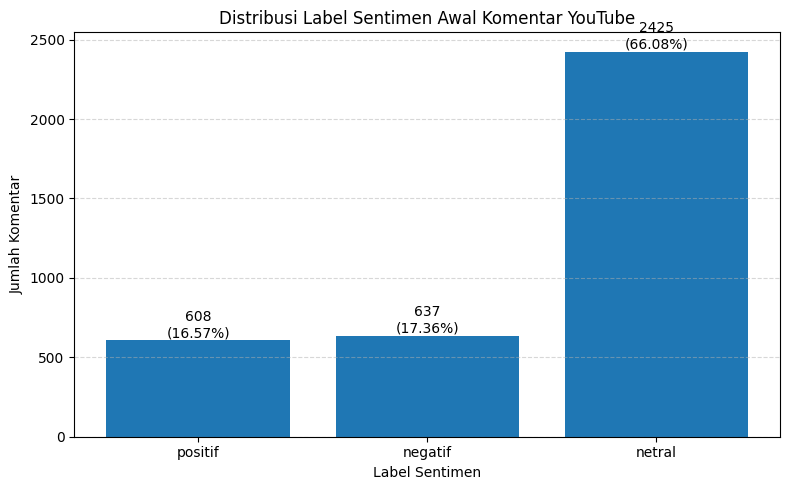

Visualisasi distribusi label berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\sentiment_label_distribution_20260529_153650.png


In [15]:
# ============================================================
# Visualisasi distribusi label sentimen
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.figure(figsize=(8, 5))
plt.bar(label_distribution["sentiment_label"].astype(str), label_distribution["count"])

plt.title("Distribusi Label Sentimen Awal Komentar YouTube")
plt.xlabel("Label Sentimen")
plt.ylabel("Jumlah Komentar")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for index, row in label_distribution.iterrows():
    plt.text(
        index,
        row["count"],
        f'{row["count"]}\n({row["percentage"]}%)',
        ha="center",
        va="bottom"
    )

plt.tight_layout()

sentiment_distribution_plot_path = REPORTS_DIR / f"sentiment_label_distribution_{timestamp}.png"
plt.savefig(sentiment_distribution_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Visualisasi distribusi label berhasil disimpan ke:")
print(sentiment_distribution_plot_path)

In [16]:
# ============================================================
# Menyimpan dataset berlabel
# ============================================================

labeled_dataset_path = LABELED_DIR / f"youtube_comments_labeled_{timestamp}.csv"

df_labeled.to_csv(labeled_dataset_path, index=False, encoding="utf-8-sig")

print("Dataset berlabel berhasil disimpan.")
print("Lokasi file:")
print(labeled_dataset_path)

print("\nCatatan:")
print("Dataset ini tidak boleh dipublikasikan ke GitHub karena masih memuat komentar asli.")

Dataset berlabel berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\labeled\youtube_comments_labeled_20260529_153650.csv

Catatan:
Dataset ini tidak boleh dipublikasikan ke GitHub karena masih memuat komentar asli.


In [17]:
# ============================================================
# Menyimpan ringkasan labeling ke reports/
# ============================================================

label_summary_path = REPORTS_DIR / f"sentiment_label_summary_{timestamp}.csv"

label_distribution.to_csv(label_summary_path, index=False, encoding="utf-8-sig")

print("Ringkasan distribusi label berhasil disimpan ke:")
print(label_summary_path)

Ringkasan distribusi label berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\sentiment_label_summary_20260529_153650.csv
